# 05 · Monotonic constraints, explanations, and the fairness audit

**The question this notebook answers:** can we *trust and explain* the model's
decisions — to a regulator, to a rejected applicant, and across groups?

Three parts: (1) force the model to move in sensible directions,
(2) explain each decision in plain language, (3) measure how decisions differ
by gender — without using gender in the model.

## 0 · Setup

In [1]:
import os, sys, json
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
from IPython.display import Image
from config.constants import TABLES_DIR, FIGURES_DIR, DATA_PROCESSED, ARTIFACTS_DIR
pd.set_option("display.width", 140)

## 1 · Monotonic constraints — and proving they hold

**What:** a *monotonic constraint* tells LightGBM that, all else equal, risk
may only go **up** as a feature goes up (e.g. payment burden) or only go
**down** (e.g. external credit score). Nine features carry such a constraint.

**Why:** an unconstrained model can learn small wiggles — "a slightly better
credit score slightly *increases* risk here" — that no credit officer could
defend. Real risk teams accept a tiny accuracy cost for defensibility.

**Why we *test* it:** the review found LightGBM's `advanced` constraint mode
violating monotonicity by up to 0.166 log-odds on these features, so the
pipeline uses `basic` mode and a **gate** checks every fold model.

**How the check works (`src.models.monotonicity.verify_monotonicity`):** take
real applicants, sweep one constrained feature across its range while holding
everything else fixed, and record the worst step in the wrong direction.
Zero = the guarantee holds. Below: a live check on a deployed fold model.

In [2]:
import lightgbm as lgb
from config.constants import MONOTONIC_FEATURES
from src.features.serving import cast_with_contract
from src.models.monotonicity import verify_monotonicity

levels = json.load(open(os.path.join(ARTIFACTS_DIR, "categorical_levels.json")))["levels"]
feats = json.load(open(os.path.join(ARTIFACTS_DIR, "lgbm_features.json")))["features"]
pool, _ = cast_with_contract(pd.read_parquet(os.path.join(ARTIFACTS_DIR, "demo_pool.parquet")), levels)
booster = lgb.Booster(model_file=os.path.join(ARTIFACTS_DIR, "lgbm_constrained_fold0.txt"))
report = verify_monotonicity(booster, pool[feats].sample(200, random_state=0), MONOTONIC_FEATURES)
pd.Series(report, name="worst violation (log-odds)")

EXT_SOURCE_1               0.0
EXT_SOURCE_2               0.0
EXT_SOURCE_3               0.0
ext_source_mean            0.0
ext_source_min             0.0
annuity_income_ratio       0.0
prev_refusal_share         0.0
bureau_bb_share_dpd_max    0.0
bureau_utilization         0.0
Name: worst violation (log-odds), dtype: float64

**The cost of the guarantee:** compare out-of-fold AUC with and without the
constraints. AUC = the probability that a randomly chosen defaulter is scored
riskier than a randomly chosen repayer (0.5 = coin flip, 1.0 = perfect).

constrained OOF AUC   0.77677
unconstrained OOF AUC 0.77735
cost of the guarantee 0.00059 AUC


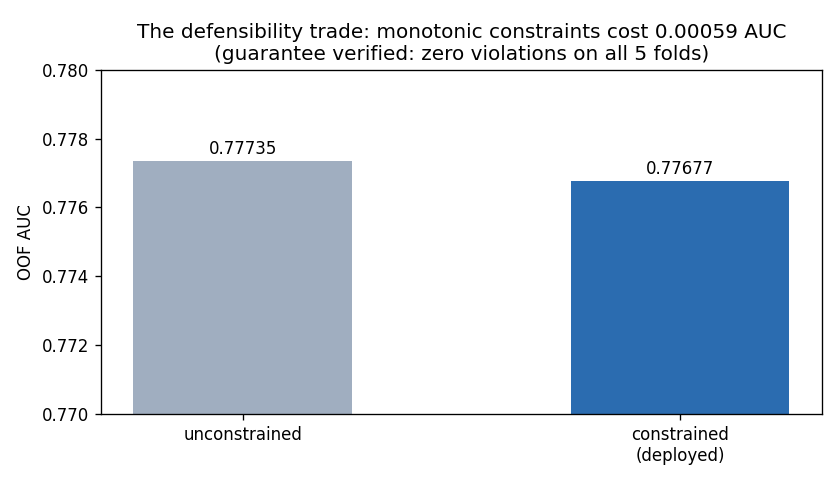

In [3]:
fp = json.load(open(os.path.join(TABLES_DIR, "final_pipeline.json")))
print(f"constrained OOF AUC   {fp['constrained_oof_auc']:.5f}")
print(f"unconstrained OOF AUC {fp['unconstrained_oof_auc']:.5f}")
print(f"cost of the guarantee {fp['auc_cost_of_constraints']:.5f} AUC")
Image(os.path.join(FIGURES_DIR, "51_constraint_cost.png"))

## 2 · Explaining a decision: SHAP and reason codes

**What SHAP is, from scratch:** a model's score for one applicant can be split
into contributions — "the base rate, plus this much because of the external
score, plus this much because of the payment burden, …" — that add up exactly
to the score. TreeSHAP computes these exactly for tree models.

**Reason codes:** the three features pushing *this* applicant's risk up the
most, translated to plain language ("low average external credit score").
This is modeled on adverse-action notices (US ECOA/Reg B; EU GDPR Art. 22) —
*inspired by*, never a compliance claim.

**One subtlety:** SHAP explains the raw score; the decision uses the
calibrated probability. Calibration never re-orders applicants, so the
explanation stays valid for the decision.

**Where:** `DeployedPipeline.score_frame` — the same code path the API uses.

In [4]:
from src.models.pipeline import DeployedPipeline

pipe = DeployedPipeline.from_artifacts()
raw_pool = pd.read_parquet(os.path.join(ARTIFACTS_DIR, "demo_pool.parquet"))
scored = pipe.score_frame(raw_pool.head(300))
for i in scored[scored.decision == "REJECT"].index[:2]:
    r = scored.loc[i]
    print(f"applicant {raw_pool.SK_ID_CURR[i]}: PD {r.pd_calibrated:.1%}, "
          f"threshold {r.threshold_applied:.3f} → {r.decision}")
    for rc in r.reason_codes:
        print(f"   • {rc['plain_language']}  (+{rc['contribution']:.2f} log-odds)")

applicant 285334: PD 13.0%, threshold 0.082 → REJECT
   • low average external credit score  (+0.72 log-odds)
   • low external credit score (worst bureau)  (+0.11 log-odds)
   • occupation profile  (+0.09 log-odds)
applicant 154810: PD 24.2%, threshold 0.064 → REJECT
   • low average external credit score  (+0.85 log-odds)
   • low external credit score (worst bureau)  (+0.26 log-odds)
   • occupation profile  (+0.14 log-odds)


**The global picture:** each dot is one applicant; position = how much that
feature moved their risk; colour = the feature's value. External credit
scores dominate, as the EDA predicted.

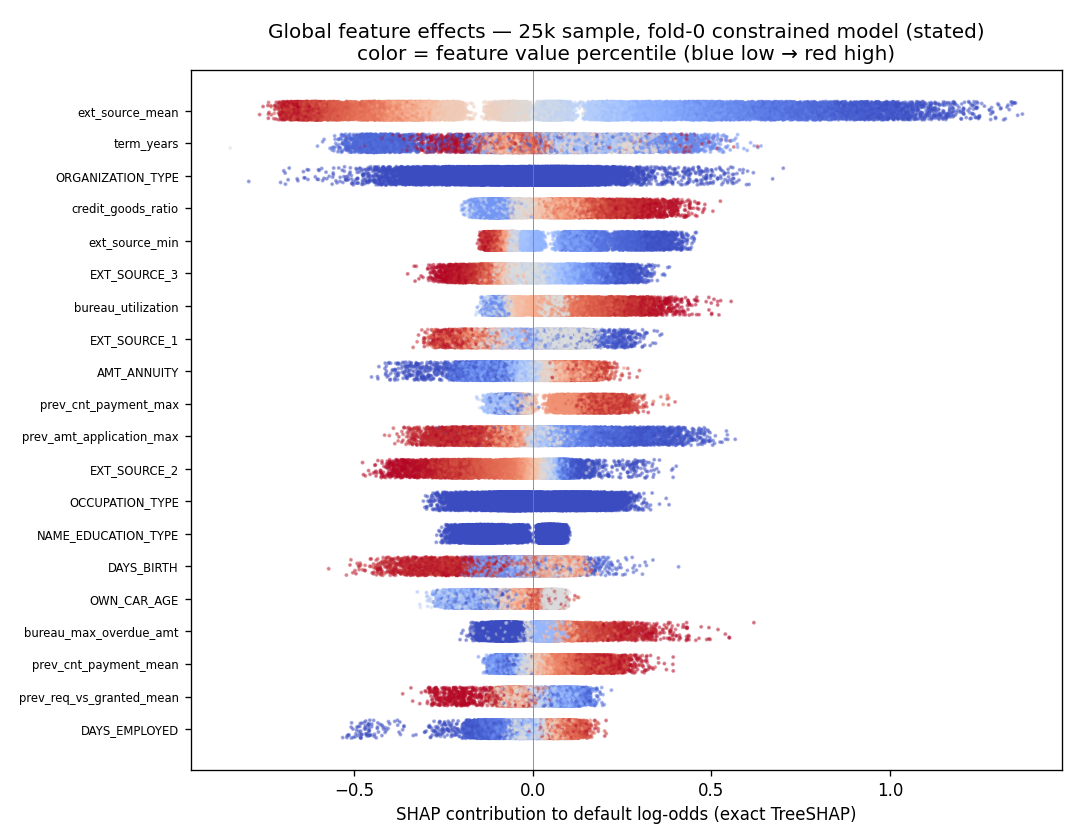

In [5]:
Image(os.path.join(FIGURES_DIR, "52_shap_beeswarm.png"))

## 3 · The fairness audit

**What:** gender (`CODE_GENDER`) is **excluded from the model** and kept only
as an audit column. We then ask three questions.

**(a) Is gender still encoded in the other features? (proxy check)** Train a
model to predict gender from the model's features. AUC near 0.5 would mean
"no gender signal left". We *pre-registered* — wrote down before running —
that it would land at 0.75–0.85, because occupation, income type and family
status carry gender signal.

**(b) Do decisions differ by group?** The **disparate impact ratio** = the
lower group's approval rate ÷ the higher group's. Below 0.80 (the
"four-fifths rule") is the conventional flag.

**(c) Is any gap coming from the model or from the policy?** Because
thresholds differ per applicant, one group could face stricter thresholds
through its product mix. We compare the average `t*(x)` by group.

**Where:** `scripts/run_phase5_fairness.py` computes the audit (proxy model
included) and writes `fairness_audit.json`; this cell loads it.

In [6]:
fa = json.load(open(os.path.join(TABLES_DIR, "fairness_audit.json")))
pc, dm = fa["proxy_check"], fa["decision_metrics"]
print(f"(a) proxy AUC {pc['proxy_oof_auc']:.3f}  (pre-registered {pc['preregistered_expectation']}, "
      f"flag {pc['flag_threshold']})")
print("    strongest gender carriers:", list(pc["top10_proxy_carriers_fold1"])[:4])
groups = pd.DataFrame({g: dm[g] for g in ("F", "M")}).T
groups = groups[["n", "base_default_rate", "approval_rate", "mean_t_star",
                 "FPR_goods_rejected", "FNR_defaulters_approved"]]
dir_ = groups.approval_rate.min() / groups.approval_rate.max()
print(f"(b) disparate impact ratio {dir_:.3f}  (flag below 0.80)")
print(f"(c) mean t*(x): F {groups.loc['F', 'mean_t_star']:.4f} vs M {groups.loc['M', 'mean_t_star']:.4f}")
groups.round(3)

(a) proxy AUC 0.907  (pre-registered [0.75, 0.85], flag 0.65)
    strongest gender carriers: ['OCCUPATION_TYPE', 'OWN_CAR_AGE', 'EXT_SOURCE_1', 'ORGANIZATION_TYPE']
(b) disparate impact ratio 0.817  (flag below 0.80)
(c) mean t*(x): F 0.0815 vs M 0.0777


,n,base_default_rate,approval_rate,mean_t_star,FPR_goods_rejected,FNR_defaulters_approved
F,161887,0.070012,0.665489,0.081536,0.307579,0.307747
M,84119,0.101356,0.543694,0.077659,0.419629,0.218508


**How to read it:**

- **(a)** The proxy AUC came out *above* the pre-registered band. Dropping the
  gender column did not remove gender from the data — which is why the audit
  looks at *decisions*, not at the feature list.
- **(b)** The ratio passes the four-fifths flag, but narrowly. It is reported
  as narrow, not clean.
- **(c)** Average thresholds barely differ between groups, so the approval
  gap is **score-driven** — it follows the different observed default rates
  (base_default_rate column) — not threshold-driven.
- **Error rates** (FPR = good customers rejected; FNR = defaulters approved)
  differ between groups. With different base rates, a score that is
  calibrated *within each group* cannot also equalize both error rates
  (Kleinberg et al. 2016; Chouldechova 2017).
- **Why no "fix":** the textbook remedy — different thresholds by gender —
  uses the protected attribute in the decision, which is itself disparate
  treatment in credit. It is named, not implemented. Scope: gender only, the
  only protected attribute in the data.

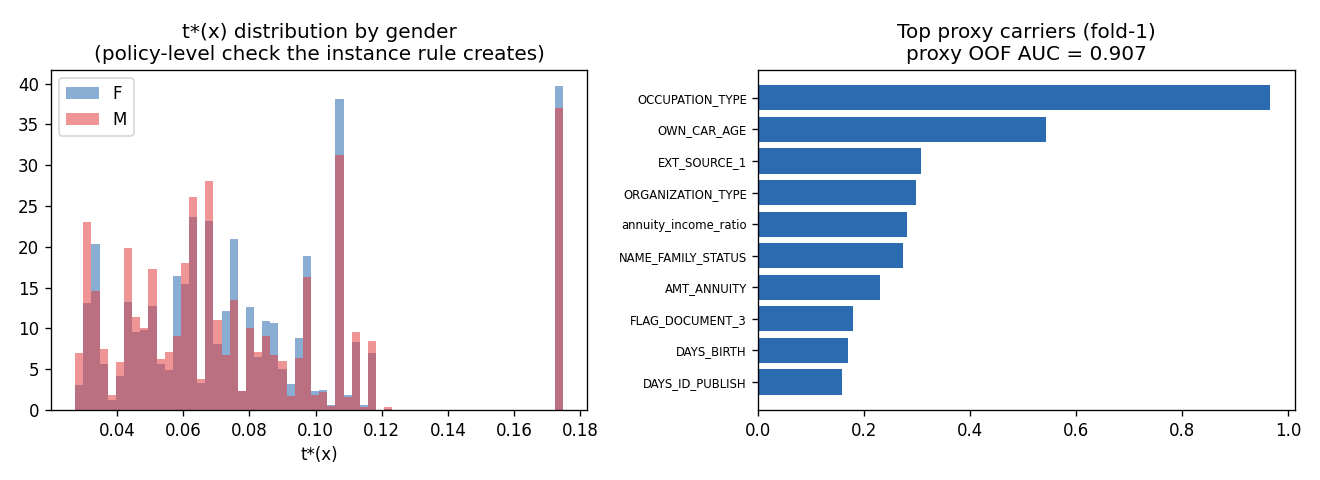

In [7]:
Image(os.path.join(FIGURES_DIR, "53_fairness.png"))

## 4 · Is the probability honest *for each group*?

**What:** section 2 of notebook 04 showed the probabilities are honest *on
average over everyone*. That does not imply they are honest for each group
separately. Here we compare mean predicted PD with the observed default rate
by gender on the development predictions.

**Why it matters:** an earlier version of the docs said this system "chose
calibration" over equal error rates. Under audit that was wrong: it is
calibrated in **aggregate** only. The check below shows women's risk slightly
**over**-predicted and men's **under**-predicted — the same pattern the holdout
showed (METHODOLOGY §6). It is measured and disclosed; group-wise
recalibration would close it but trades against the error-rate gaps.

In [8]:
audit = pd.read_parquet(os.path.join(DATA_PROCESSED, "audit_frame.parquet"))
oof = pd.read_parquet(os.path.join(DATA_PROCESSED, "oof_constrained_calibrated.parquet"))
g = (oof.merge(audit[["SK_ID_CURR", "CODE_GENDER"]], on="SK_ID_CURR")
        .query("CODE_GENDER in ['F', 'M']")
        .groupby("CODE_GENDER")
        .agg(n=("TARGET", "size"), observed=("TARGET", "mean"), predicted=("p_cal_crossfit", "mean")))
g["relative_error"] = g.predicted / g.observed - 1
g.round(4)

,n,observed,predicted,relative_error
CODE_GENDER,,,,
F,161887,0.0700,0.0736,0.0511
M,84119,0.1014,0.0945,-0.0678
